In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [226]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [227]:
df.shape

(3559, 18)

In [228]:
df['sector'] = df['sector'].str.replace('sohna road road', 'sohna road')

In [229]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37d,1.60,7303.0,4,3,3+,7.0,Relatively New,2000.0,0,0,0,0,1,1,139
1,flat,dlf express greens,manesar,1.60,6809.0,4,6,3+,4.0,Relatively New,2611.0,1,1,0,1,0,0,49
2,flat,mapsko royale ville,sector 82,1.12,8000.0,3,4,2,6.0,Relatively New,1500.0,0,1,0,1,0,1,174
3,flat,dlf regal gardens,sector 90,1.25,7340.0,3,3,3,28.0,Moderately Old,1540.0,0,1,0,0,0,0,38
4,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,Relatively New,1261.0,0,0,0,0,0,0,0


In [230]:
  latlong = pd.read_csv('latlong.csv')

In [231]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
5,sector 6,"28.4745° N, 77.0262° E"
6,sector 7,"28.4644° N, 77.0143° E"
7,sector 8,"28.4614° N, 77.0209° E"
8,sector 9,"28.4603° N, 77.0000° E"
9,sector 10,"28.4537° N, 77.0009° E"


In [232]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [233]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [234]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [235]:
new_df = df.merge(latlong, on='sector')

In [236]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,flat,bptp terra,sector 37d,1.60,7303.0,4,3,3+,7.0,Relatively New,...,0,0,0,0,1,1,139,"28.4478° N, 76.9703° E",28.4478,76.9703
1,flat,dlf express greens,manesar,1.60,6809.0,4,6,3+,4.0,Relatively New,...,1,1,0,1,0,0,49,"28.3515° N, 76.9428° E",28.3515,76.9428
2,flat,mapsko royale ville,sector 82,1.12,8000.0,3,4,2,6.0,Relatively New,...,0,1,0,1,0,1,174,"28.3935° N, 76.9600° E",28.3935,76.9600
3,flat,dlf regal gardens,sector 90,1.25,7340.0,3,3,3,28.0,Moderately Old,...,0,1,0,0,0,0,38,"28.4085° N, 76.9369° E",28.4085,76.9369
4,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,Relatively New,...,0,0,0,0,0,0,0,"28.4079° N, 76.9153° E",28.4079,76.9153


In [237]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()


In [238]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3054.222222,28.4484,77.0210
manesar,0.962258,4608.064516,2026.851613,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.333333,28.3663,76.9456
sector 102,1.696636,10603.822430,1555.327103,28.4750,76.9715
sector 103,1.495000,7445.785714,1864.761905,28.4949,76.9845
sector 104,1.622388,8873.895522,1834.656716,28.4788,76.9960
sector 105,1.198000,10168.950000,1118.125500,28.4952,77.0114
sector 106,1.548421,8591.000000,1505.842105,28.5007,77.0003
sector 107,0.776102,6643.915254,1102.305085,28.5052,76.9729


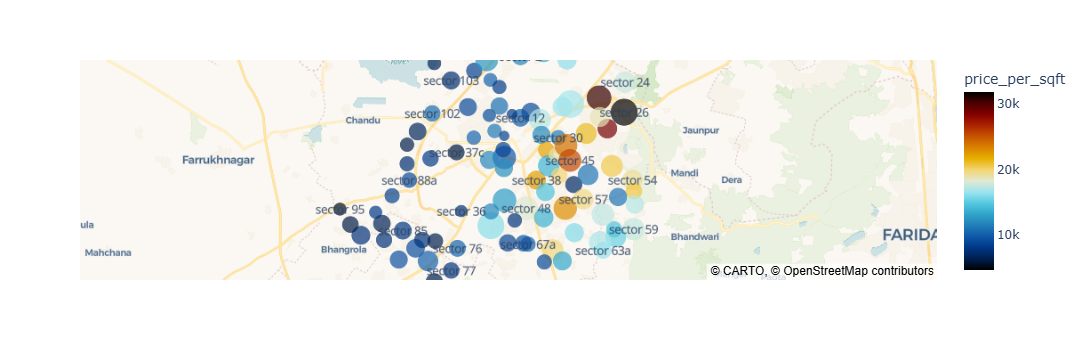

In [239]:
fig = px.scatter_map(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size="built_up_area",
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,  text=group_df.index)

fig.show()

In [240]:
new_df.to_csv('data_viz1.csv',index=False)

In [241]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [242]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,4 BHK Flat in Sector 37D Gurgaon,flat,bptp terra,1.60,7302.0,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up...,4,3,3+,others,"A701, Sector 37D Gurgaon, Gurgaon, Haryana",7.0,North,1 to 5 Year Old,"['Airia Mall', 'Dwarka Expressway', 'Golf Cour...",This is a super luxury property which is situa...,"['1 Wardrobe', '5 Fan', '1 Exhaust Fan', '21 L...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area4.5 out of 5', 'Construction4.5 ou..."
1,4 BHK Flat in Sector 1A IMT Manesar,flat,dlf express greens,1.60,6808.0,2350.0,Carpet area: 2350 (218.32 sq.m.),4,6,3+,"study room,pooja room,servant room","Sector 1A IMT Manesar, Gurgaon, Haryana",4.0,North-East,1 to 5 Year Old,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash ...",East facing and cornet flat plus also park fac...,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area5 out of 5', 'Construction3.5 out ..."
2,3 BHK Flat in Sector 82 Gurgaon,flat,mapsko royale ville,1.12,8000.0,1400.0,Super Built up area 1790(166.3 sq.m.)Built Up ...,3,4,2,"pooja room,servant room","000, Sector 82 Gurgaon, Gurgaon, Haryana",6.0,North-West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Golf Course Ext Rd', ""St...",Mapsko royale ville is one of gurgaon's most s...,"['4 Fan', '1 Exhaust Fan', '7 Light', '1 Modul...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area4.5 out of 5', 'Construction3 out ..."
3,3 BHK Flat in Sector 90 Gurgaon,flat,dlf regal gardens,1.25,7339.0,1703.0,Super Built up area 1703(158.21 sq.m.),3,3,3,servant room,"123, Sector 90 Gurgaon, Gurgaon, Haryana",28.0,North,5 to 10 Year Old,"['SS Omnia, Sector 86', 'Numberdar market, IMT...",This 3 bhk apartment is available for sale in ...,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s...","['Green Area5 out of 5', 'Construction4.5 out ..."
4,3 BHK Flat in Sector 92 Gurgaon,flat,sare green parc,0.85,6741.0,1261.0,Built Up area: 1261 (117.15 sq.m.),3,2,2,not available,"Sector 92, Sector 92 Gurgaon, Gurgaon, Haryana",14.0,NaN,undefined,"['Huda city centre metro station', 'Iffco chow...",Multistorey apartment is available for sale. I...,NaN,NaN,"['Environment5 out of 5', 'Lifestyle4 out of 5..."


In [243]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [244]:
# pd.set_option('display.max_rows', None)
# df['sector'].nunique()
df['sector'].shape
# df['sector'].value_counts()

(3559,)

In [245]:
import ast
secwise = {}

for sector in wordcloud_df['sector'].unique():
    all_features = []
    for item in wordcloud_df[wordcloud_df['sector'] == sector]['features'].dropna().apply(ast.literal_eval):
        all_features.extend(item)
    secwise[sector] = all_features


In [246]:
import json

with open('secwise.txt', 'w') as f:
    json.dump(secwise, f)

In [247]:
import pickle
pickle.dump(secwise, open('secwise.pkl', 'wb'))

In [248]:
from wordcloud import WordCloud

In [249]:
feature_text = ' '.join(secwise['sector 37d'])

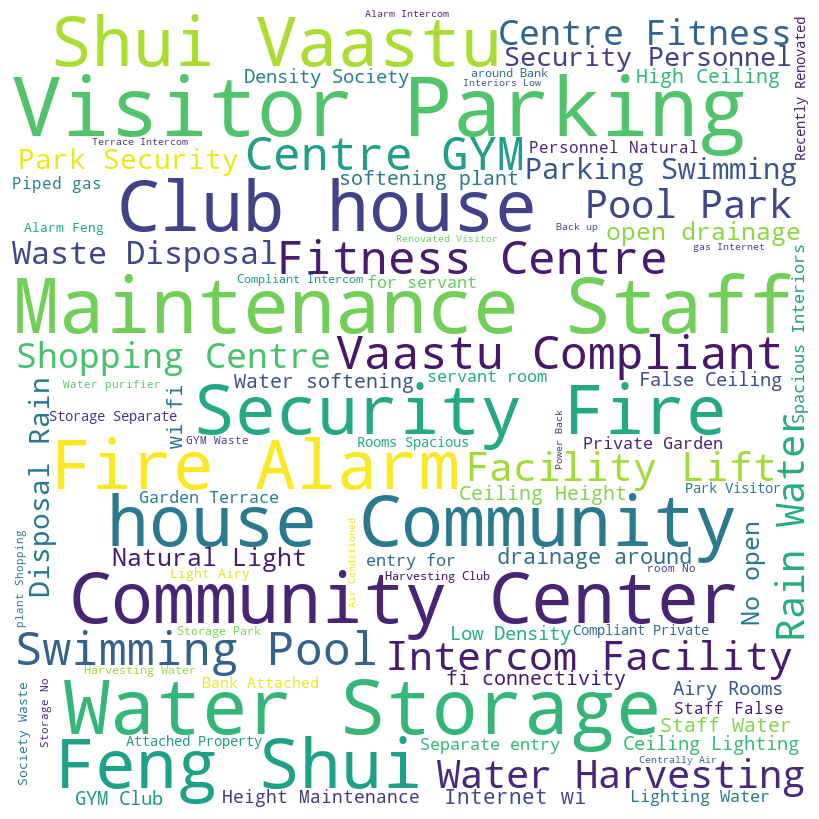

In [250]:
plt.rcParams['font.family'] = 'Arial'

wordcloud = WordCloud(width = 800, height = 800,
                     background_color='white',
                     stopwords = set(['s']),  # Any stopwords you'd like to exlude
                     min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8,8), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()  #st.pyplot

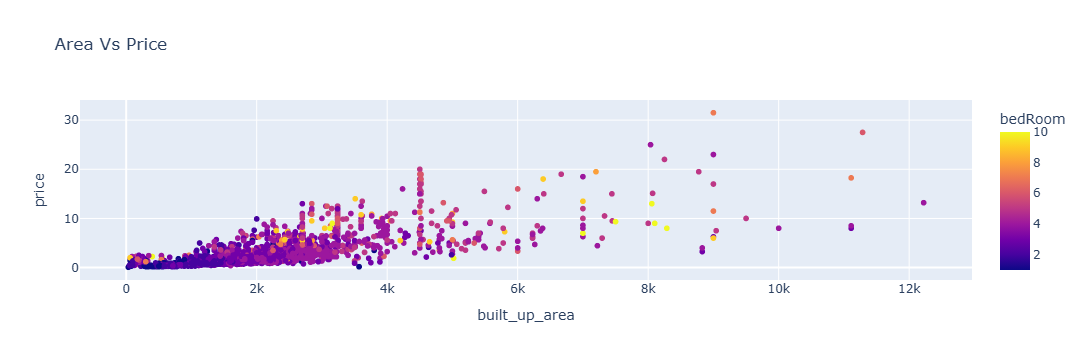

In [251]:
fig = px.scatter(df, x='built_up_area', y='price', color='bedRoom', title='Area Vs Price')

fig.show()

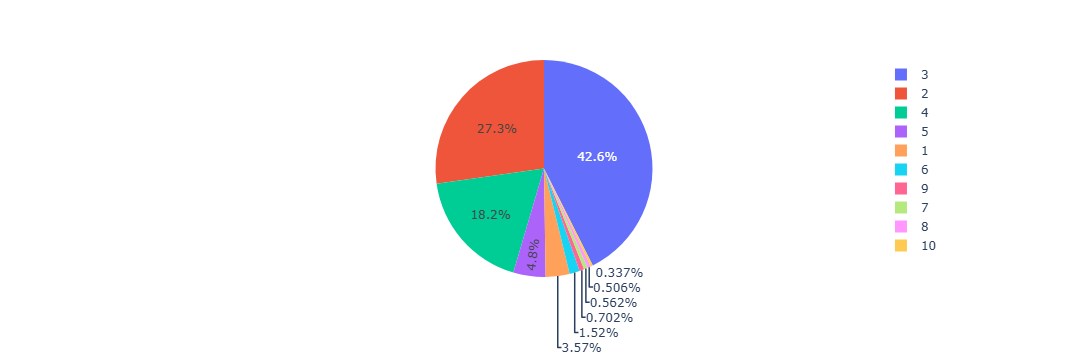

In [252]:
fig = px.pie(df, names='bedRoom')

fig.show()

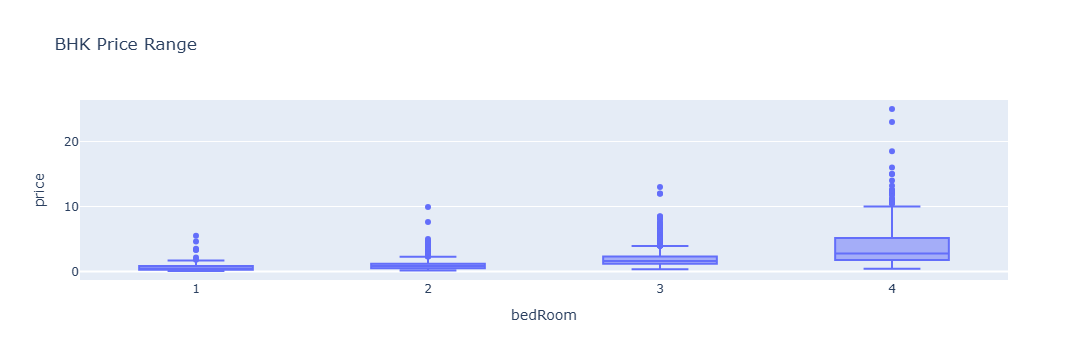

In [253]:
temp_df = df[df['bedRoom'] <=4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\vamsh\AppData\Local\Temp\ipykernel_43440\2094281588.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\vamsh\AppData\Local\Temp\ipykernel_43440\2094281588.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

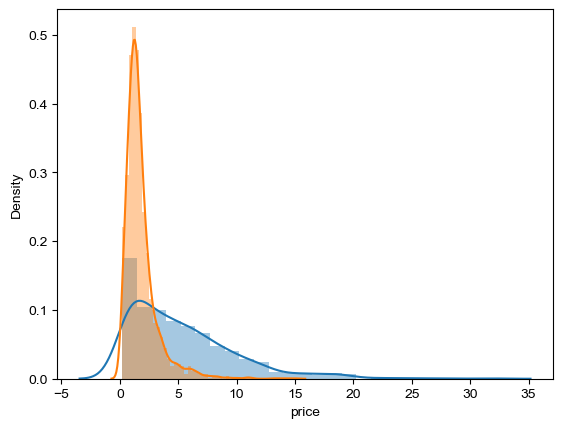

In [254]:
# fig4 = plt.figure(figsize=(10,4))
sns.distplot(new_df[new_df['property_type']=='house']['price'])
sns.distplot(new_df[new_df['property_type']=='flat']['price'])

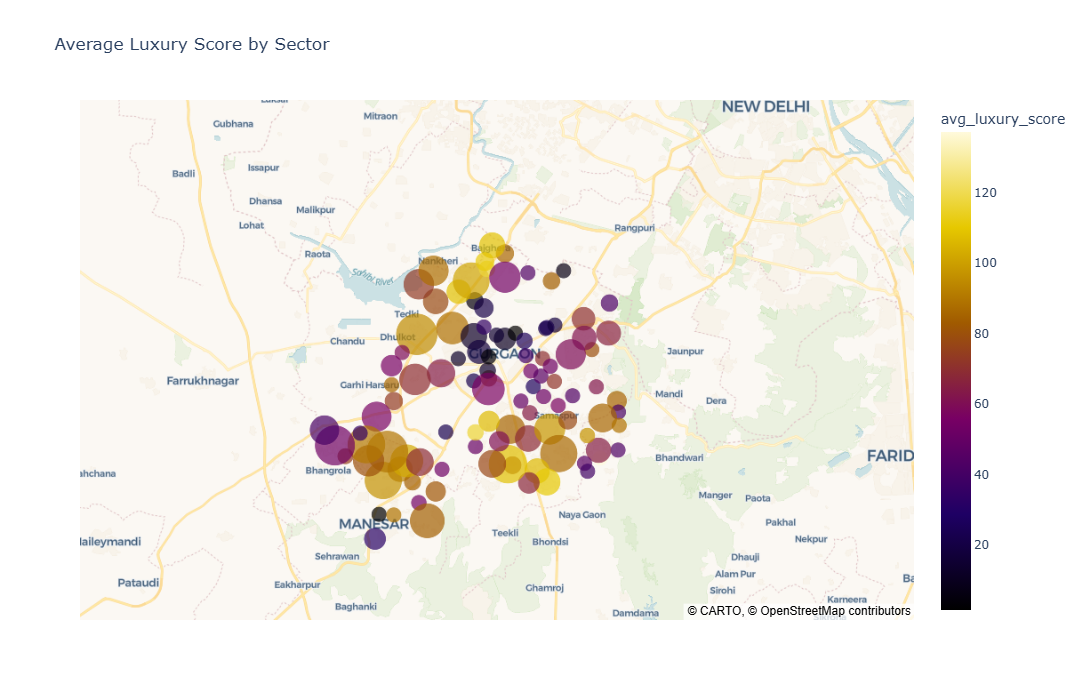

In [293]:
group2_df = new_df.groupby('sector').agg(
    latitude=('latitude', 'mean'),
    longitude=('longitude', 'mean'),
    avg_luxury_score=('luxury_score', 'mean'),
    property_count=('luxury_score', 'count')
).reset_index()

fig = px.scatter_map(
    group2_df, lat='latitude', lon='longitude',
    size='property_count', color='avg_luxury_score',
    hover_name='sector',
    hover_data={
        'property_count': True,
        'avg_luxury_score': ':.1f',
        'latitude': False,
        'longitude': False
    },
    color_continuous_scale='electric',
    zoom=10, center={'lat': 28.4595, 'lon': 77.0266},
    size_max=30,
    title='Average Luxury Score by Sector'
)
fig.update_traces(marker=dict(sizemin=8))
fig.update_layout(height=700)
fig.show()